# Cryptocurrency Price Prediction using Simple RNN
This notebook converts timestamp data to daily format and builds an RNN model for price prediction.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


## Step 1: Load & Convert Timestamp to Date


In [ ]:
import pandas as pd

# Skip first 2 rows (Price / Ticker rows)
df = pd.read_csv("BTC_daily.csv", skiprows=2)

# Rename columns properly
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Set as index
df.set_index('Date', inplace=True)

# Sort by date (important!)
df = df.sort_index()

print(df.head())

                 Close        High         Low        Open    Volume
Date                                                                
2014-09-17  457.334015  468.174011  452.421997  465.864014  21056800
2014-09-18  424.440002  456.859985  413.104004  456.859985  34483200
2014-09-19  394.795990  427.834991  384.532013  424.102997  37919700
2014-09-20  408.903992  423.295990  389.882996  394.673004  36863600
2014-09-21  398.821014  412.425995  393.181000  408.084991  26580100


## Step 2: Use Close Price Only


In [ ]:
data = df[['Close']]


## Step 3: Normalize Data


In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)


## Step 4: Create Time Series Sequences


In [ ]:
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 60)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))


## Step 5: Train-Test Split


In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


## Step 6: Build RNN Model


In [ ]:
model = Sequential()
model.add(SimpleRNN(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(SimpleRNN(50))
model.add(Dense(1))
model.compile(optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

| Parameter               | Explanation                        |
| ----------------------- | ---------------------------------- |
| `50`                    | number of RNN neurons              |
| `return_sequences=True` | output sequence for next RNN layer |
| `input_shape=(60,1)`    | 60 time steps, 1 feature           |


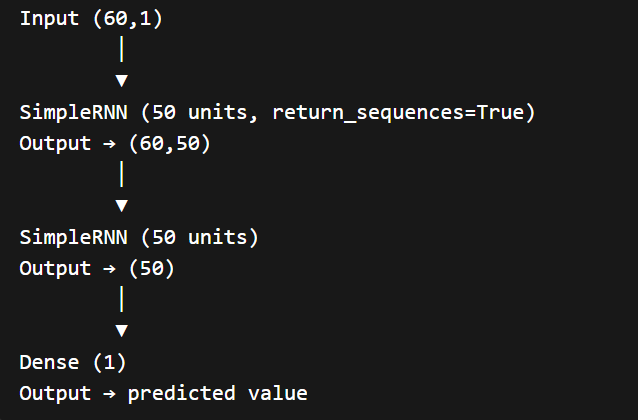

## Step 7: Train Model


In [ ]:
model.fit(X_train, y_train, epochs=20, batch_size=32)


Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0455 - mae: 0.0808
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 3.2030e-04 - mae: 0.0112
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 2.2308e-04 - mae: 0.0094
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 2.0136e-04 - mae: 0.0093
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.7018e-04 - mae: 0.0083
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.3040e-04 - mae: 0.0073
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.2880e-04 - mae: 0.0079
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 1.1235e-04 - mae: 0.0069
Epoch 9/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.2725e-04 - mae: 0.0074
Epoch 10/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1.3311e-04 - mae: 0.0079
Epoch 11/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 7.3205e-05 - mae: 0.0053
Epoch 12/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - 

this is a very small error.

✔ Model predictions are very close to actual values.

## Step 8: Make Predictions


In [ ]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [ ]:
#predict for the next date in the future
last_60_days = scaled_data[-60:]

last_60_days = last_60_days.reshape(1,60,1)

next_day_prediction = model.predict(last_60_days)

next_day_prediction = scaler.inverse_transform(next_day_prediction)

print("Next day predicted value:", next_day_prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Next day predicted value: [[68408.05]]


Deep learning models return outputs as 2D arrays

In [ ]:
#Evaluate Model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)
r2 = r2_score(y_test_actual, predictions)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 7594.469922198562
MAE: 5675.661620074423
R2: 0.892449093753179


## Step 9: Plot Results


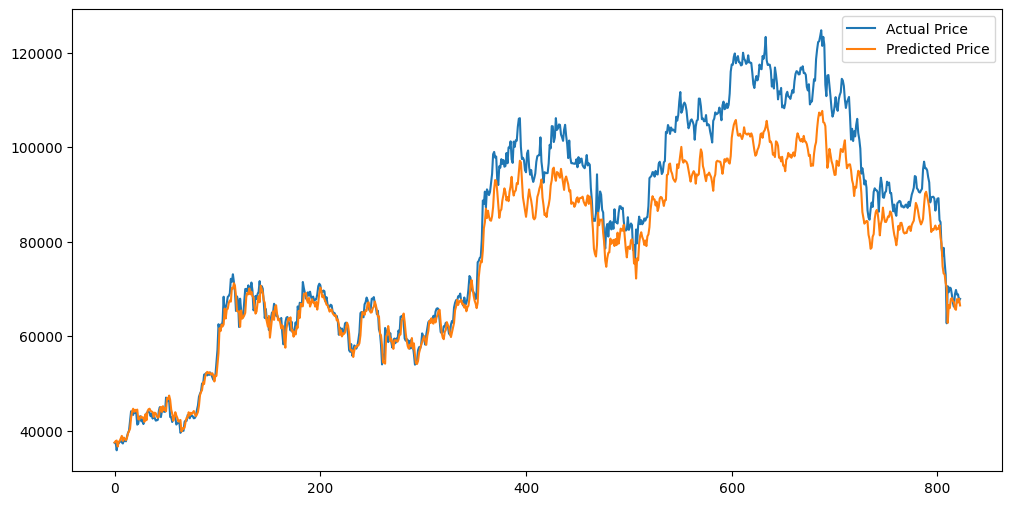

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.legend()
plt.show()


What This Means About Your Model

Your model is:

✅ Good at learning trend direction
✅ Good at learning general pattern

But:

❌ Not good at predicting large spikes
❌ Slight underprediction bias

# Interview Concepts

Since you're preparing for interviews, be ready to answer:

1️⃣ Why scale data?

Because RNN uses gradient descent and large values cause unstable training.

2️⃣ Why time-based split?

To prevent data leakage.

3️⃣ Why RNN instead of Linear Regression?

RNN captures temporal dependencies.

4️⃣ Limitation of Simple RNN?

Vanishing gradient problem → cannot remember long-term dependencies.

🔥 How To Make It Stronger

After building this, upgrade to:

LSTM

GRU

Add Moving Averages

Compare with ARIMA

Predict next 7 days

📄Description

Built a univariate time series forecasting model using Simple RNN to predict Bitcoin closing prices based on historical trends. Implemented sliding window technique, time-based data splitting, MinMax scaling, and evaluated performance using RMSE.

In [ ]:
import yfinance as yf

btc = yf.download("BTC-USD", period="max", interval="1d")
btc.to_csv("BTC_daily.csv")

/tmp/ipykernel_651/2116996727.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", period="max", interval="1d")
[*********************100%***********************]  1 of 1 completed
